In [2]:
import pandas as pd

df = pd.read_csv(
    "../data/processed/scri_dataset.csv"
)

df.head()

,lat,lon,mean_annual_rf,std_annual,cv,dry_days,heavy_days,rf_norm,cv_norm,dry_norm,heavy_norm,scri,risk_tier,scri_z
0,8.25,77.00,1368.70980,409.68338,0.299321,253.051282,0.487179,0.142809,0.971563,0.544681,0.982680,0.640340,High,0.706958
1,8.25,77.25,1163.10000,317.94876,0.273363,265.871795,0.487179,0.120985,0.975863,0.481214,0.982680,0.622174,High,0.389884
2,8.25,77.50,749.88873,343.41086,0.457949,313.076923,0.282051,0.077127,0.945286,0.247525,0.989973,0.556458,Moderate,-0.757169
3,8.25,77.75,758.49920,328.97153,0.433714,294.102564,0.256410,0.078041,0.949300,0.341457,0.990884,0.576750,Moderate,-0.402976
4,8.50,76.75,1833.17690,363.57733,0.198332,233.205128,0.820513,0.192108,0.988292,0.642930,0.970830,0.675999,Critical,1.329369


In [3]:
X = df[
    [
        "mean_annual_rf",
        "std_annual",
        "cv",
        "dry_days",
        "heavy_days"
    ]
]

In [4]:
y = df["risk_tier"]

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

In [7]:
pred = rf.predict(X_test)

In [8]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        pred
    )
)

              precision    recall  f1-score   support

    Critical       0.98      0.98      0.98       132
        High       0.98      0.98      0.98       299
         Low       0.96      0.99      0.97       135
    Moderate       0.98      0.98      0.98       427

    accuracy                           0.98       993
   macro avg       0.98      0.98      0.98       993
weighted avg       0.98      0.98      0.98       993



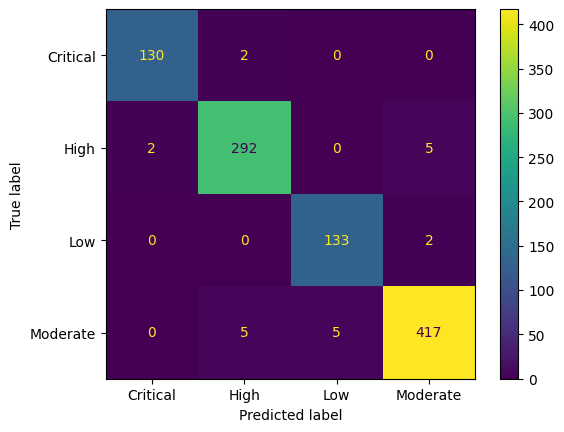

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.show()

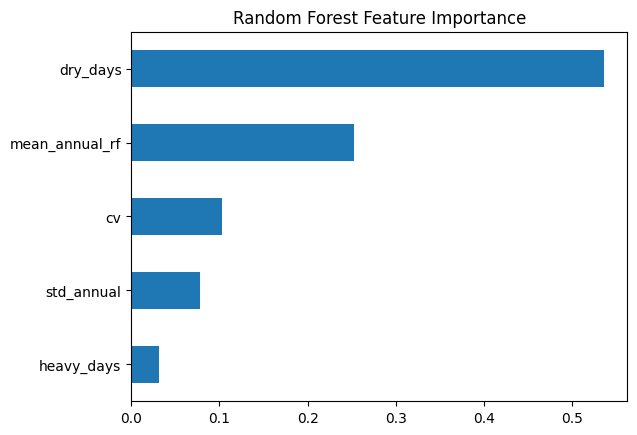

In [10]:
import pandas as pd

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot.barh()

plt.title(
    "Random Forest Feature Importance"
)

plt.show()

In [11]:
df.columns

Index(['lat', 'lon', 'mean_annual_rf', 'std_annual', 'cv', 'dry_days',
       'heavy_days', 'rf_norm', 'cv_norm', 'dry_norm', 'heavy_norm', 'scri',
       'risk_tier', 'scri_z'],
      dtype='object')

In [13]:
df["risk_tier"].value_counts()

risk_tier
Moderate    2134
High        1496
Low          676
Critical     658
Name: count, dtype: int64

In [12]:
from sklearn.metrics import accuracy_score, classification_report

pred = rf.predict(X_test)

print(
    f"Accuracy = {accuracy_score(y_test,pred)*100:.2f}%"
)

print(
    classification_report(
        y_test,
        pred
    )
)

Accuracy = 97.89%
              precision    recall  f1-score   support

    Critical       0.98      0.98      0.98       132
        High       0.98      0.98      0.98       299
         Low       0.96      0.99      0.97       135
    Moderate       0.98      0.98      0.98       427

    accuracy                           0.98       993
   macro avg       0.98      0.98      0.98       993
weighted avg       0.98      0.98      0.98       993



F1 SCORE 


In [14]:
from sklearn.metrics import f1_score

print(
    f"F1 Score: {f1_score(y_test, pred, average='weighted'):.4f}"
)

F1 Score: 0.9789
